In [1]:
import numpy as np
import pandas  as pd             #1.1
from unicodedata import numeric

from homework.example import data

df=pd.read_csv("catalog_products.xlsx - Sheet1 (1).csv")
print("всего строк и столбцов:\n",df.shape)
print("типы данных у каждой колонки:\n",df.dtypes)
print("пропущенные значения:\n",df.isnull().sum())
print("5 строк таблицы:\n",df.head(5))

всего строк и столбцов:
 (10000, 50)
типы данных у каждой колонки:
 col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object
пропущенные значения:
 col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0

In [2]:
df=pd.read_csv("catalog_products.xlsx - Sheet1 (1).csv")       #1.2
numeric_cols=df.select_dtypes(include=[np.number]).columns
df[numeric_cols]=df[numeric_cols].astype(float)
df[numeric_cols]=df[numeric_cols].fillna(df[numeric_cols].mean())
print(df[numeric_cols].isna().sum())

col_2     0
col_3     0
col_5     0
col_6     0
col_8     0
col_9     0
col_11    0
col_12    0
col_14    0
col_15    0
col_17    0
col_18    0
col_20    0
col_21    0
col_23    0
col_24    0
col_26    0
col_27    0
col_29    0
col_30    0
col_32    0
col_33    0
col_35    0
col_36    0
col_38    0
col_39    0
col_41    0
col_42    0
col_44    0
col_45    0
col_47    0
col_48    0
col_50    0
dtype: int64


In [3]:
import numpy as np   #1.3
df["total_value"]=df["col_2"]*df["col_3"]
df["double_stock"]=df["col_3"]*2
df["log_price"]=np.log(df["col_2"])
print(df)

         col_1  col_2  col_3        col_4  col_5  col_6        col_7  col_8  \
0         Home  762.0  303.0  Electronics   49.0  348.0     Clothing  206.0   
1       Sports  190.0   34.0       Sports  107.0   99.0     Clothing  836.0   
2        Books  711.0    2.0         Home   93.0  876.0         Home  868.0   
3       Sports  484.0  362.0        Books  636.0  361.0         Home  897.0   
4       Sports  733.0  195.0         Home  829.0  937.0     Clothing  428.0   
...        ...    ...    ...          ...    ...    ...          ...    ...   
9995  Clothing  444.0  107.0         Home  429.0    1.0        Books   71.0   
9996     Books  434.0  857.0  Electronics  831.0  437.0       Sports  764.0   
9997  Clothing  228.0  937.0        Books  648.0  686.0  Electronics  847.0   
9998      Home  509.0  291.0       Sports  666.0  250.0     Clothing  231.0   
9999     Books  799.0  349.0        Books  294.0  410.0        Books  524.0   

      col_9       col_10  ...  col_44  col_45      

In [4]:
df_4 = df[["col_2", "col_7"]]       #1.4
electronics_expensive=df_4[(df_4["col_2"]>500) & (df_4["col_7"]=='Electronics')].copy()
print(electronics_expensive.head(5))

    col_2        col_7
10  605.0  Electronics
16  670.0  Electronics
63  926.0  Electronics
66  716.0  Electronics
70  937.0  Electronics


In [5]:
df_5=df.groupby("col_7").agg(       #1.5
    mean_price=("col_2","mean"),
    max_price=("col_2","max"),
    total_quantity=("col_3","sum")
).reset_index()
df_5=df_5.rename(columns={"col_7":"category"})
print(df_5)

      category  mean_price  max_price  total_quantity
0        Books  494.009027      999.0        982076.0
1     Clothing  495.738608      999.0       1008454.0
2  Electronics  505.886228      999.0       1009669.0
3         Home  511.097561      999.0        995489.0
4       Sports  509.046637      999.0       1008988.0


In [6]:
df_6=df[["col_2","col_3","col_5","col_6","col_8","col_9","col_11"]]  #1.6
statistics=[]
for col in df_6:
    statistics.append({
        "column":col,
        "mean":df[col].mean(),
        "median":df[col].median(),
        "std":df[col].std()
    })
res=pd.DataFrame(statistics)
print(res)

   column      mean  median         std
0   col_2  503.1608   509.0  289.808030
1   col_3  500.4676   502.5  288.052132
2   col_5  494.9370   493.0  290.634660
3   col_6  500.0842   502.0  287.772049
4   col_8  500.1320   498.0  287.280092
5   col_9  494.8945   488.0  288.756643
6  col_11  499.8112   501.0  287.426535


In [7]:
mean_col2=np.mean(df['col_2'])  #1.7
std_col2=np.std(df['col_2'])
anomalies=df[df['col_2']>mean_col2+3*std_col2]
print(anomalies.head(5))

Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price]
Index: []

[0 rows x 53 columns]


In [8]:
crl=df[["col_2","col_3","col_5","col_6","col_8","col_9","col_11"]]    #1.8
matrix_crl=crl.corr()
print(matrix_crl)

           col_2     col_3     col_5     col_6     col_8     col_9    col_11
col_2   1.000000 -0.006128 -0.002368 -0.004579  0.019838 -0.008986 -0.006885
col_3  -0.006128  1.000000  0.020303  0.004545  0.014136  0.004623  0.002812
col_5  -0.002368  0.020303  1.000000  0.022725  0.015310  0.013237 -0.000047
col_6  -0.004579  0.004545  0.022725  1.000000 -0.005012  0.002743 -0.019907
col_8   0.019838  0.014136  0.015310 -0.005012  1.000000 -0.008199  0.002730
col_9  -0.008986  0.004623  0.013237  0.002743 -0.008199  1.000000  0.017898
col_11 -0.006885  0.002812 -0.000047 -0.019907  0.002730  0.017898  1.000000


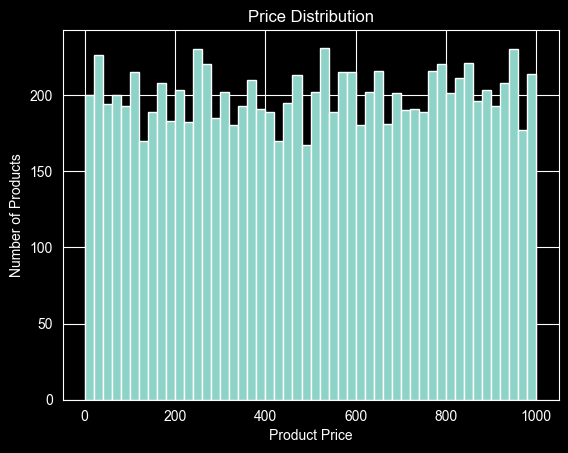

In [9]:
import matplotlib.pyplot as plt       #1.9
plt.hist(df['col_2'],bins=50)
plt.title("Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Products")
plt.grid(True)
plt.show()


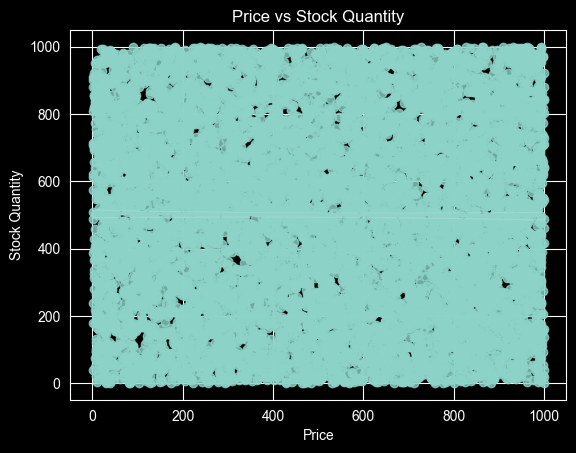

In [10]:
import seaborn as sns       #1.10
sns.regplot(x=df["col_2"],y=df["col_3"])
plt.title("Price vs Stock Quantity")
plt.xlabel("Price")
plt.ylabel("Stock Quantity")
plt.show()

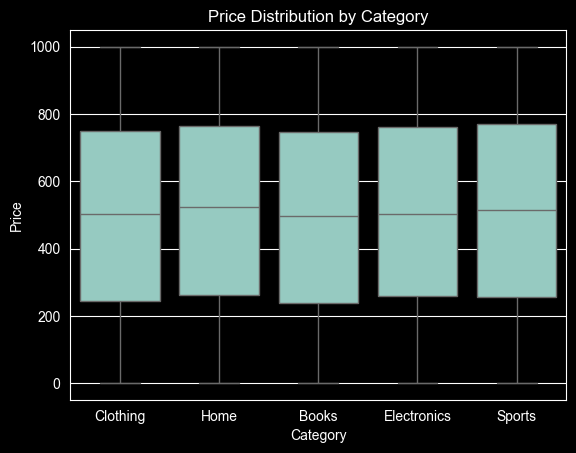

In [11]:
sns.boxplot(x=df["col_7"],y=df["col_2"])    #1.11
plt.title("Price Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Price")
plt.show()

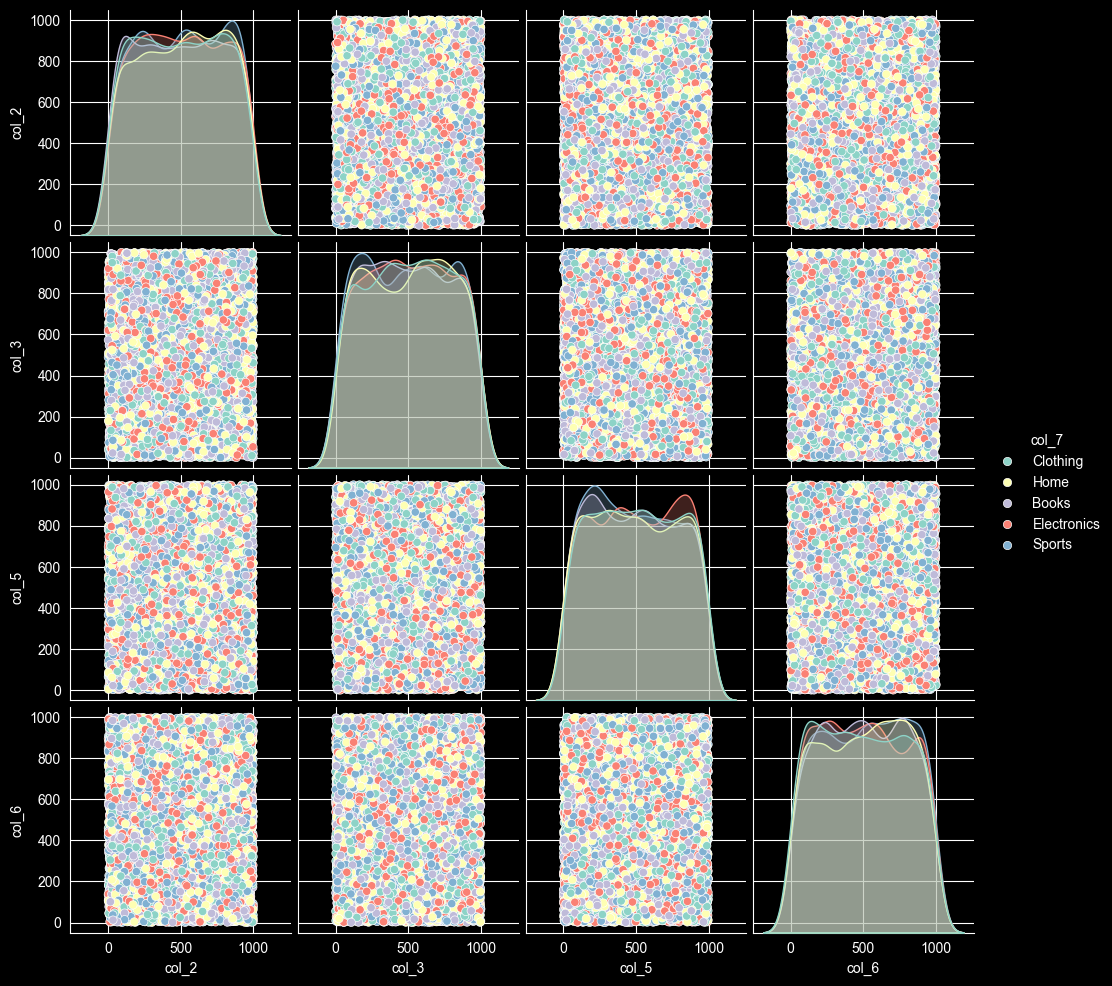

In [12]:
df_12=df[["col_2","col_3","col_4","col_5","col_6","col_7"]]         #1.12
sns.pairplot(df_12, hue="col_7")
plt.show()

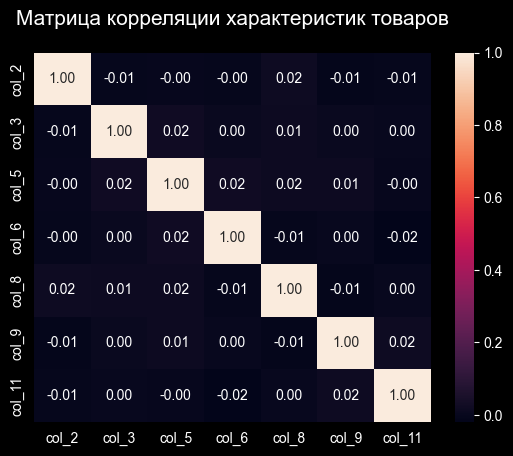

In [21]:
sns.heatmap(matrix_crl,         #1.13
            annot=True,
            fmt=".2f")
plt.title('Матрица корреляции характеристик товаров', fontsize=15, pad=20)
plt.show()

In [22]:
df.to_excel("catalog_analysis.xlsx",index=False)       #1.14

In [25]:
category_summary = df.groupby('col_7').agg(          #1.15
    total_products=('col_2', 'count'),
    average_price=('col_2', 'mean'),
    total_stock=('col_3', 'sum'),
    avg_log_price=('log_price', 'mean')
)
print(category_summary.head(5))

             total_products  average_price  total_stock  avg_log_price
col_7                                                                 
Books                  1994     494.009027     982076.0       5.879360
Clothing               1997     495.738608    1008454.0       5.892562
Electronics            2004     505.886228    1009669.0       5.933533
Home                   1968     511.097561     995489.0       5.935257
Sports                 2037     509.046637    1008988.0       5.939490


In [40]:
df_16=df.groupby("col_7")['col_2'].idxmax()                  #1.16
most_expensive=df.loc[df_16,["col_1","col_2","col_7"]]
print(most_expensive)

         col_1  col_2        col_7
1117    Sports  999.0        Books
1019      Home  999.0     Clothing
1478    Sports  999.0  Electronics
3101  Clothing  999.0         Home
2890    Sports  999.0       Sports


In [47]:
df_17=df[["col_1","col_2","col_3","total_value"]].sort_values("total_value",ascending=False)       #1.17
print(df_17.head(10))

            col_1  col_2  col_3  total_value
3833        Books  994.0  999.0     993006.0
4494       Sports  993.0  997.0     990021.0
9335     Clothing  994.0  992.0     986048.0
6431         Home  988.0  981.0     969228.0
3725  Electronics  997.0  971.0     968087.0
3389  Electronics  986.0  979.0     965294.0
3026  Electronics  997.0  968.0     965096.0
9202       Sports  966.0  996.0     962136.0
1380  Electronics  963.0  998.0     961074.0
3956     Clothing  982.0  975.0     957450.0


In [55]:
df["price_range"]=pd.cut(                #1.18
    df["col_2"],
    bins=[0,50,200,500,1000,float("inf")],
    labels=["0-50","50-200","200-500","500-1000","1000+"]
)
df_18=df.groupby("price_range").agg(
    count=("price_range","count")
).reset_index()
print(df_18)

  price_range  count
0        0-50    525
1      50-200   1453
2     200-500   2939
3    500-1000   5083


In [57]:
df_19=df.groupby("col_7").agg(        #1.19
    total_stock_value=("total_value","sum")
).reset_index()
print(df_19)

         col_7  total_stock_value
0        Books        485388939.0
1     Clothing        500261132.0
2  Electronics        506372840.0
3         Home        509060773.0
4       Sports        511957866.0


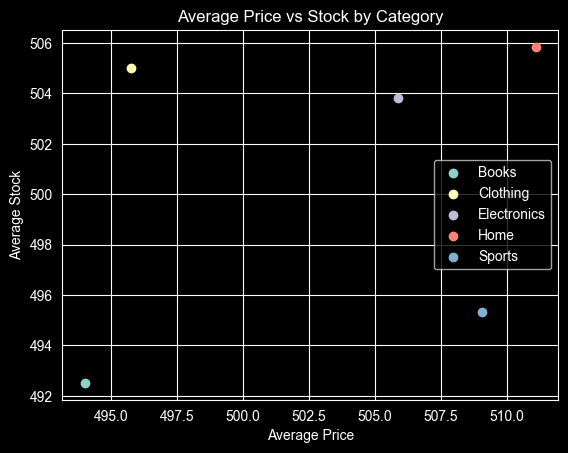

In [58]:
grouped=df.groupby('col_7').agg({         #1.20
    'col_2':'mean',
    'col_3':'mean'
}).reset_index()

grouped.columns = ['category','avg_price','avg_stock']

plt.figure()

for category in grouped['category']:
    subset = grouped[grouped['category']==category]
    plt.scatter(subset['avg_price'],subset['avg_stock'],label=category)
plt.xlabel('Average Price')
plt.ylabel('Average Stock')
plt.title('Average Price vs Stock by Category')
plt.legend()

plt.show()

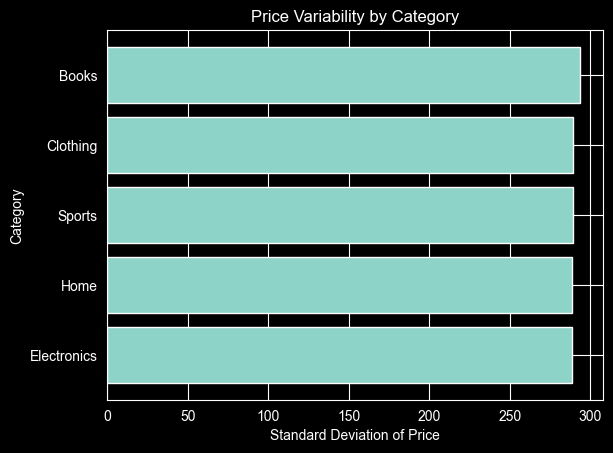

In [61]:
grouped=df.groupby('col_7').agg({        #1.21
    'col_2':'std'
}).reset_index()

grouped.columns=['category', 'std_price']

grouped=grouped.sort_values(by='std_price', ascending=True)

plt.figure()
plt.barh(grouped['category'], grouped['std_price'])

plt.xlabel('Standard Deviation of Price')
plt.ylabel('Category')
plt.title('Price Variability by Category')

plt.show()

In [63]:
out_of_stock=df[df['col_3']==0]          #1.22

result=out_of_stock[['col_1','col_7','col_2']].head(10)
print(result)

Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


Топ-5 категорий по количеству товаров:
         col_7  count
4       Sports   2037
2  Electronics   2004
1     Clothing   1997
0        Books   1994
3         Home   1968


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6496\3509638648.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


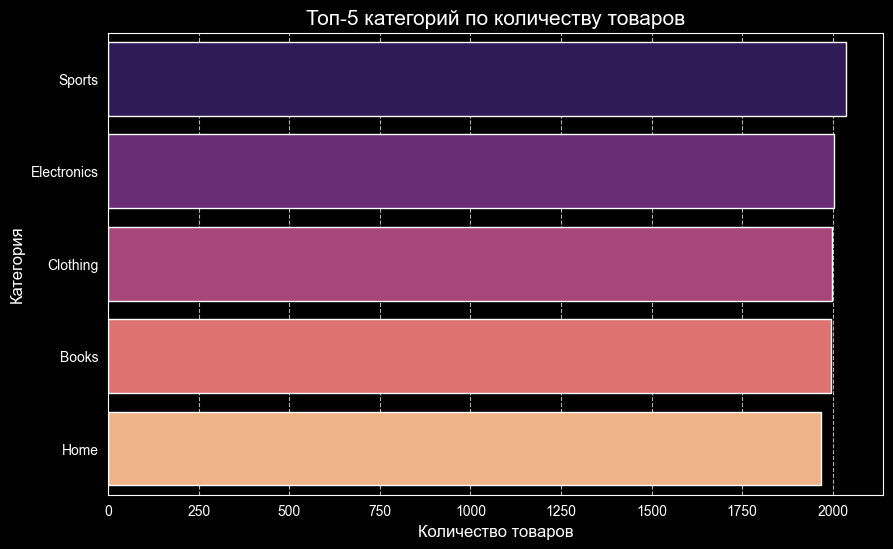

In [73]:
top_categories=df.groupby('col_7').size().reset_index(name='count')         #1.23
top_5=top_categories.sort_values('count',ascending=False).head(5)
print("Топ-5 категорий по количеству товаров:")
print(top_5)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_5,
    x='count',
    y='col_7',
    palette='magma'
)
plt.title('Топ-5 категорий по количеству товаров', fontsize=15)
plt.xlabel('Количество товаров', fontsize=12)
plt.ylabel('Категория', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

            col_1  col_3
3833        Books  999.0
8167        Books  999.0
7108  Electronics  999.0
7337     Clothing  998.0
1380  Electronics  998.0
8460         Home  998.0
5448     Clothing  998.0
8606  Electronics  998.0
9003     Clothing  998.0
3577         Home  998.0


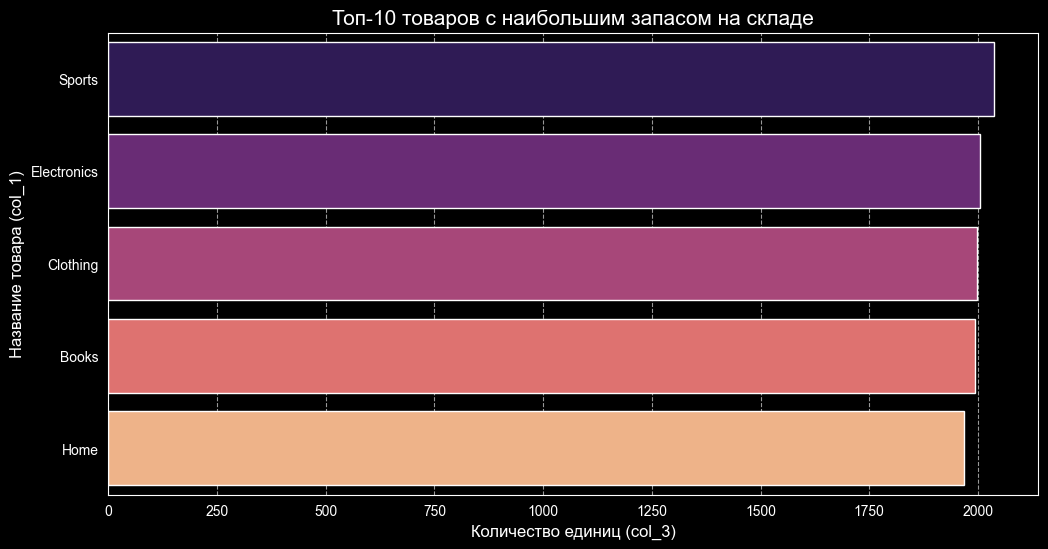

In [76]:
top_stock_items=df.sort_values('col_3',ascending=False).head(10)        #1.24
print(top_stock_items[['col_1', 'col_3']])

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_5,
    x='count',
    y='col_7',
    hue='col_7',
    palette='magma',
    legend=False
)

plt.title('Топ-10 товаров с наибольшим запасом на складе',fontsize=15)
plt.xlabel('Количество единиц (col_3)',fontsize=12)
plt.ylabel('Название товара (col_1)',fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

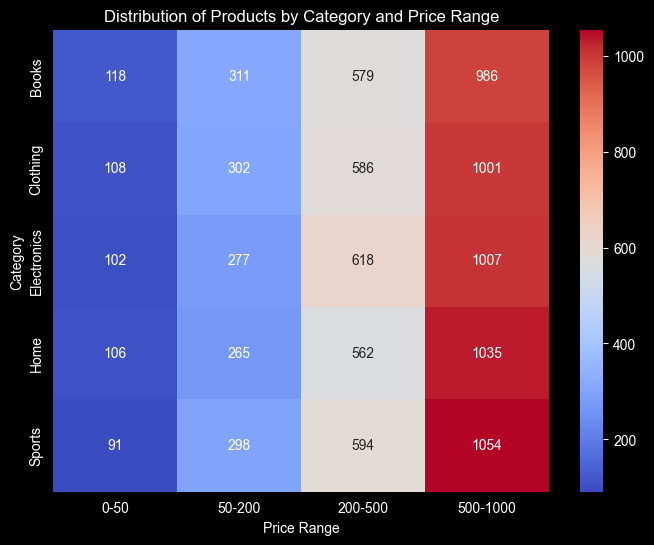

In [75]:
pivot = pd.pivot_table(        #1.25
    df,
    index='col_7',
    columns='price_range',
    values='col_2',
    aggfunc='count',
    fill_value=0
)
plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='g', cmap='coolwarm')
plt.xlabel('Price Range')
plt.ylabel('Category')
plt.title('Distribution of Products by Category and Price Range')

plt.show()

         col_7  mean_price  mean_quantity
0        Books  494.009027     492.515547
1     Clothing  495.738608     504.984477
2  Electronics  505.886228     503.826846
3         Home  511.097561     505.837907
4       Sports  509.046637     495.330388


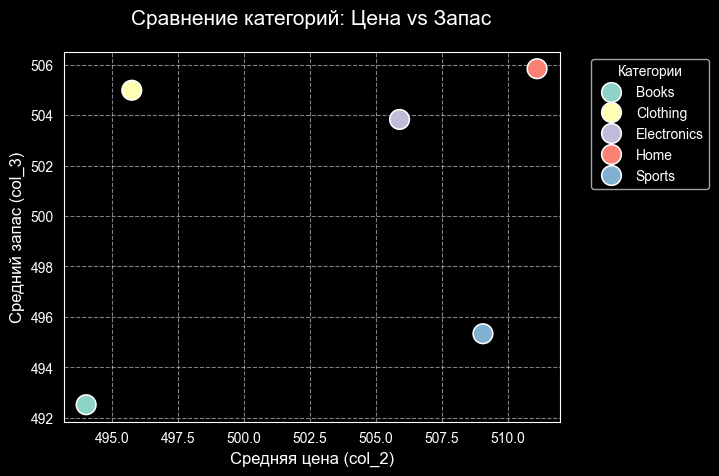

In [80]:
category_analysis=df.groupby('col_7').agg(        #1.36
    mean_price=('col_2', 'mean'),
    mean_quantity=('col_3', 'mean')
).reset_index()
print(category_analysis)

sns.scatterplot(
    data=category_analysis,
    x='mean_price',
    y='mean_quantity',
    hue='col_7',
    s=200
)

plt.title('Сравнение категорий: Цена vs Запас', fontsize=15, pad=20)
plt.xlabel('Средняя цена (col_2)', fontsize=12)
plt.ylabel('Средний запас (col_3)', fontsize=12)
plt.legend(title='Категории', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

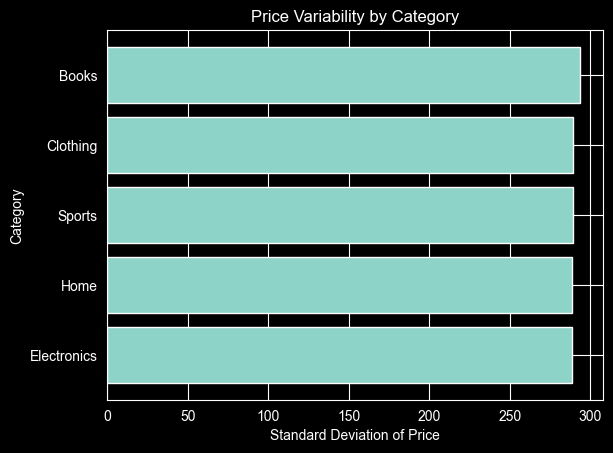

In [81]:
grouped = df.groupby('col_7')['col_2'].std().reset_index()        #1.37

grouped.columns = ['category','std_price']
grouped = grouped.sort_values('std_price', ascending=True)
plt.figure()
plt.barh(grouped['category'], grouped['std_price'])
plt.xlabel('Standard Deviation of Price')
plt.ylabel('Category')
plt.title('Price Variability by Category')

plt.show()

In [82]:
out_of_stock = df[df['col_3'] == 0]             #1.38
result = out_of_stock[['col_1', 'col_7', 'col_2']]
print("Список товаров с нулевым запасом (первые 10):")
print(result.head(10))

Список товаров с нулевым запасом (первые 10):
Empty DataFrame
Columns: [col_1, col_7, col_2]
Index: []


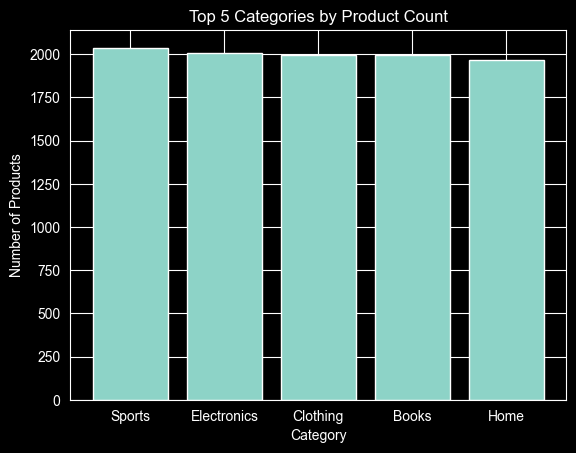

In [85]:
grouped = df.groupby('col_7').size().reset_index(name='count')          #1.39
top5 = grouped.sort_values(by='count',ascending=False).head(5)
plt.figure()
plt.bar(top5['col_7'], top5['count'])
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.title('Top 5 Categories by Product Count')
plt.show()

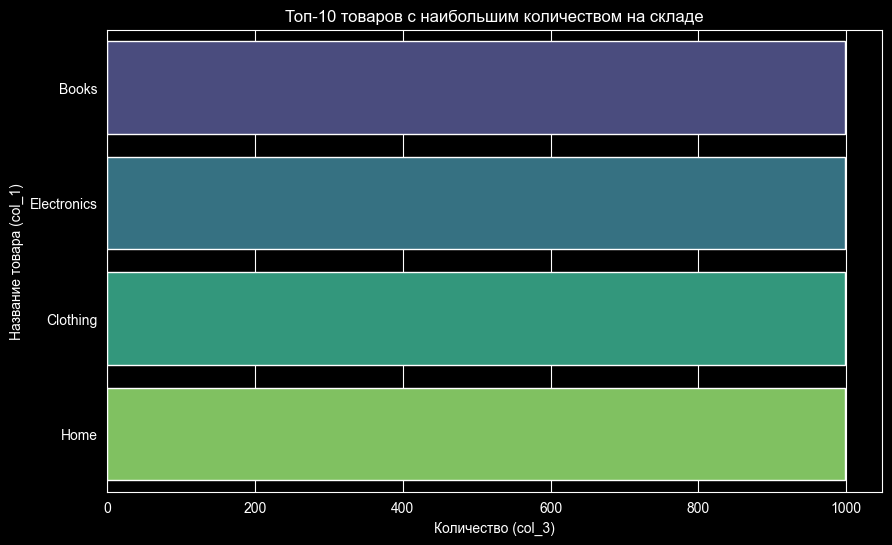

In [87]:
top_stock_items = df.sort_values(by='col_3', ascending=False).head(10)          #1.40
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_stock_items,
    x='col_3',
    y='col_1',
    hue='col_1',
    palette='viridis',
    legend=False
)

plt.title('Топ-10 товаров с наибольшим количеством на складе')
plt.xlabel('Количество (col_3)')
plt.ylabel('Название товара (col_1)')
plt.show()

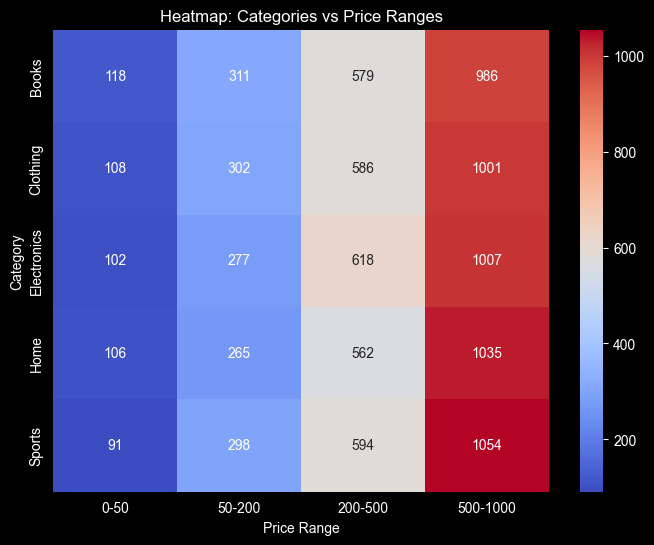

In [88]:
pivot = pd.pivot_table(       #1.41
    df,
    index='col_7',
    columns='price_range',
    values='col_2',
    aggfunc='count',
    fill_value=0
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='g', cmap='coolwarm')
plt.xlabel('Price Range')
plt.ylabel('Category')
plt.title('Heatmap: Categories vs Price Ranges')
plt.show()

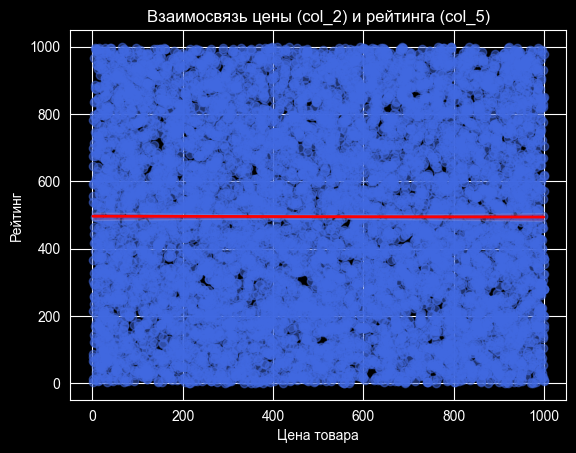

In [89]:
sns.regplot(             #1.42
    data=df,
    x='col_2',
    y='col_5',
    scatter_kws={'alpha': 0.5, 'color': 'royalblue'},
    line_kws={'color': 'red', 'lw': 2}
)
plt.title('Взаимосвязь цены (col_2) и рейтинга (col_5)')
plt.xlabel('Цена товара')
plt.ylabel('Рейтинг')
plt.show()

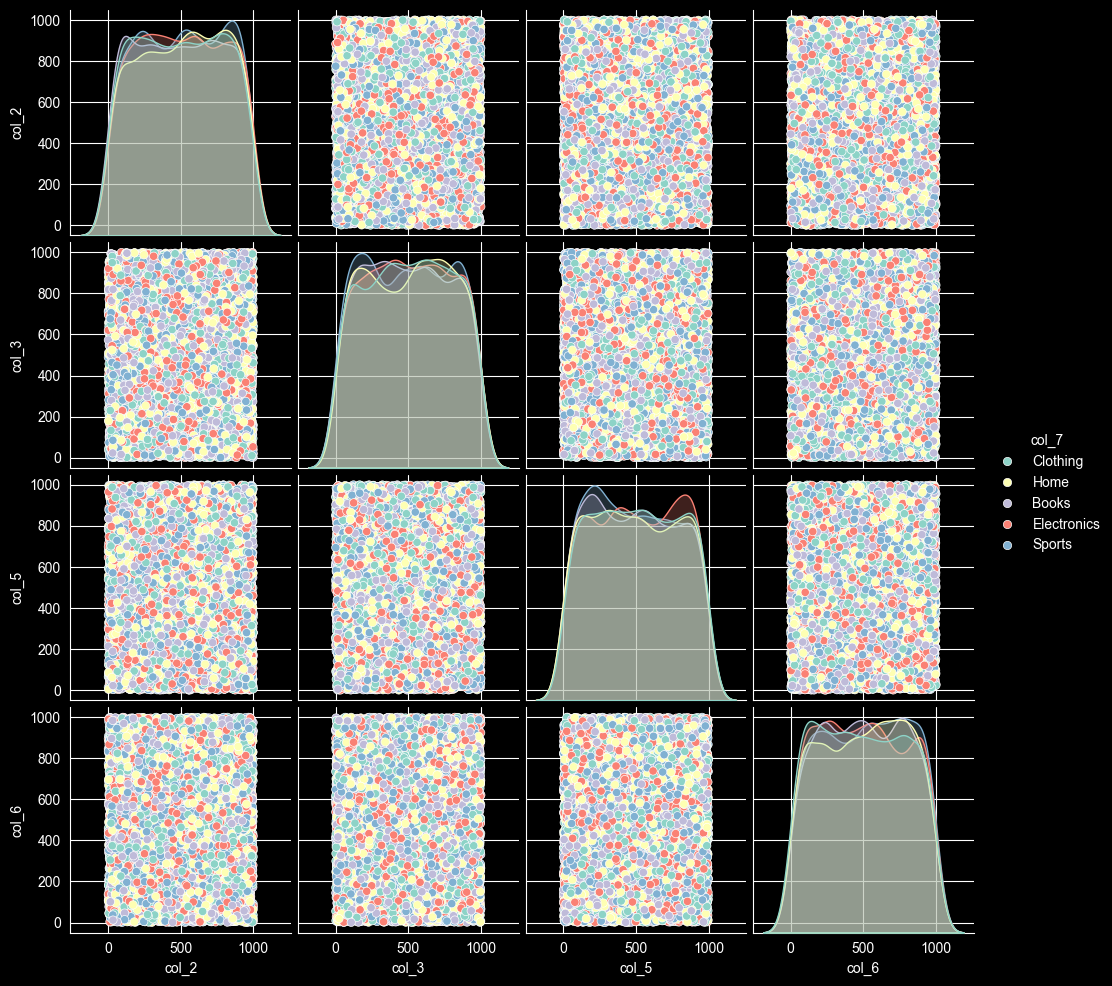

In [90]:
cols = ['col_2','col_3','col_4','col_5','col_6','col_7']           #1.43
sns.pairplot(df[cols], hue='col_7')
plt.show()

In [91]:
mean_price=df['col_2'].mean()          #1.44
std_price=df['col_2'].std()

mean_stock=df['col_3'].mean()
std_stock=df['col_3'].std()

price_threshold=mean_price+ 3*std_price
stock_threshold=mean_stock+3*std_stock

extreme_items=df[(df['col_2']>price_threshold)|(df['col_3']>stock_threshold)]

print(f"Порог аномальной цены: {price_threshold:.2f}")
print(f"Порог аномального запаса: {stock_threshold:.2f}")
print(f"Найдено аномальных товаров: {len(extreme_items)}")
print(extreme_items.head())

Порог аномальной цены: 1372.58
Порог аномального запаса: 1364.62
Найдено аномальных товаров: 0
Empty DataFrame
Columns: [col_1, col_2, col_3, col_4, col_5, col_6, col_7, col_8, col_9, col_10, col_11, col_12, col_13, col_14, col_15, col_16, col_17, col_18, col_19, col_20, col_21, col_22, col_23, col_24, col_25, col_26, col_27, col_28, col_29, col_30, col_31, col_32, col_33, col_34, col_35, col_36, col_37, col_38, col_39, col_40, col_41, col_42, col_43, col_44, col_45, col_46, col_47, col_48, col_49, col_50, total_value, double_stock, log_price, price_rang, price_range]
Index: []

[0 rows x 55 columns]


In [93]:
category_summary = df.groupby('col_7').agg(
    avg_price=('col_2','mean'),
    total_stock=('col_3','sum')
).reset_index()
top_stock=df.sort_values(by='col_3',ascending=False).head(10)
top_value=df.sort_values(by='total_value',ascending=False).head(10)
with pd.ExcelWriter('catalog_final_report.xlsx') as writer:
    df.to_excel(writer,sheet_name='Full Data',index=False)
    category_summary.to_excel(writer,sheet_name='Category Summary',index=False)
    top_stock.to_excel(writer,sheet_name='Top Stock',index=False)
    top_value.to_excel(writer,sheet_name='Top Value',index=False)